In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import gridspec
import seaborn as sns
import matplotlib as mpl
import matplotlib.patches as patches
from matplotlib.ticker import FuncFormatter
from scipy.sparse import diags
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
import json
import anndata as ad
import scanpy as sc
import cellspec as spc

%matplotlib inline

In [2]:
colors = [
    '#FF1B5E',  # coral
    '#FFDB57',  # yellow
    '#438CFD',  # blue
    '#FF8C00',  # orange
    '#80F15E',  # lime green
    '#03FFFF',  # cyan
    '#5941A9',  # purple
    '#E980FC',  # magenta
    '#1A1A2E',  # navy
    '#F5F0FF',  # lavender white
    '#C17F3E',  # amber brown
]

In [3]:
import matplotlib.font_manager as fm
import os, glob


fm._load_fontmanager(try_read_cache=False)
# Register TeX Gyre Heros if present
for f in glob.glob(os.path.expanduser("~/.local/share/fonts/texgyreheros*.otf")):
    fm.fontManager.addfont(f)

In [4]:
mpl.rcParams.update({
    # Font
    "font.family": "sans-serif",
    "font.sans-serif": ["TeX Gyre Heros"],
    "font.size": 12,

    "axes.linewidth": 2.5,
    # Tick marks
    "xtick.major.width": 2.5,
    "ytick.major.width": 2.5,
    "xtick.minor.width": 2.0,
    "ytick.minor.width": 2.0,

    # Tick direction (outward is common in publications)
    "xtick.direction": "out",
    "ytick.direction": "out",
})

# Coverage and read count

In [5]:
data = pd.read_csv('/fh/working/srivatsan_s/Dustin/worm6-dubnova-100k-align/pooled_sc_qc_metrics.csv', index_col='barcode')
data

,sample,total_reads,aligned_reads,pct_aligned,mean_read_length,mean_insert_size,read_duplicates,pct_duplicates,exonic_reads,exonic_enrichment,splice_reads,pct_1x,pct_5x,pct_10x,mean_coverage,median_coverage,gini,unique_aligned_reads,bam_path
barcode,,,,,,,,,,,,,,,,,,,
A10_A7_B4_F2_worm6_UDI1,worm6_UDI1,191454,86634,0.452506,113,285.7,8432,0.194658,40560,0.468176,1484,0.023025,0.002218,0.000449,0.051922,0,0.968077,69770,/fh/working/srivatsan_s/Dustin/worm6-dubnova-1...
A10_A7_C5_G1_worm6_UDI1,worm6_UDI1,139822,59936,0.428659,113,185.8,5788,0.193139,27502,0.458856,2733,0.011541,0.001702,0.000504,0.035169,0,0.987483,48360,/fh/working/srivatsan_s/Dustin/worm6-dubnova-1...
A10_A7_D4_C1_worm6_UDI1,worm6_UDI1,243050,119974,0.493619,113,279.1,11491,0.191558,54686,0.455815,2369,0.029281,0.003405,0.000716,0.071939,0,0.962704,96992,/fh/working/srivatsan_s/Dustin/worm6-dubnova-1...
A10_A7_E5_C1_worm6_UDI1,worm6_UDI1,139808,49844,0.356518,113,329.3,4697,0.188468,19312,0.387449,1478,0.011670,0.001212,0.000312,0.029618,0,0.984803,40450,/fh/working/srivatsan_s/Dustin/worm6-dubnova-1...
A10_A7_E5_G3_worm6_UDI1,worm6_UDI1,733960,119348,0.162608,116,173.1,13220,0.221537,58661,0.491512,1561,0.023375,0.003721,0.001221,0.068468,0,0.976135,92908,/fh/working/srivatsan_s/Dustin/worm6-dubnova-1...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
H12_G7_G4_G1_worm6_UDI24,worm6_UDI24,135850,62560,0.460508,113,195.2,7700,0.246164,27205,0.434863,1676,0.012707,0.001806,0.000470,0.035368,0,0.985054,47160,/fh/working/srivatsan_s/Dustin/worm6-dubnova-1...
H12_G7_H5_G1_worm6_UDI24,worm6_UDI24,185710,56620,0.304884,115,210.1,6870,0.242670,21990,0.388379,1372,0.011680,0.001413,0.000418,0.032563,0,0.986628,42880,/fh/working/srivatsan_s/Dustin/worm6-dubnova-1...
H12_H7_A4_D2_worm6_UDI24,worm6_UDI24,138564,42150,0.304192,115,329.0,5050,0.239620,17336,0.411293,2249,0.010537,0.000916,0.000179,0.023708,0,0.985016,32050,/fh/working/srivatsan_s/Dustin/worm6-dubnova-1...


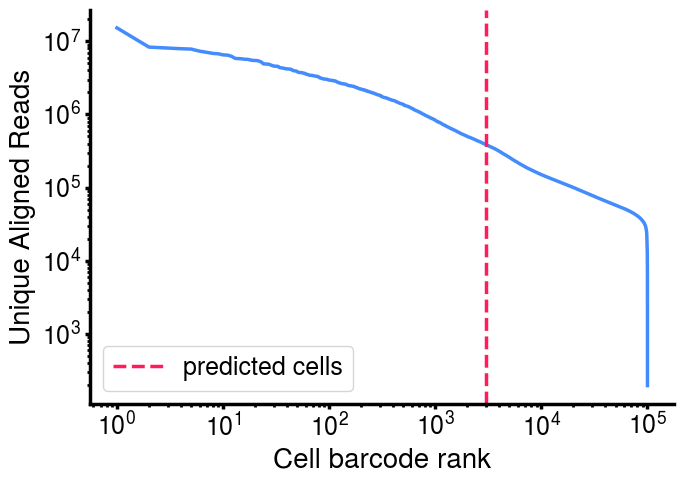

In [6]:
counts_descending = data.unique_aligned_reads.sort_values(ascending=False)
n = len(counts_descending)
ranks = np.arange(1, n + 1)

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(ranks, counts_descending, color=colors[2], linewidth=2.5)

plt.axvline(x=3000, color=colors[0], label='predicted cells', linestyle='--', linewidth=2.5)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Cell barcode rank", fontsize=20)
ax.set_ylabel("Unique Aligned Reads", fontsize=20)
plt.legend(fontsize=18)

ax.tick_params(labelsize=18)
fig.tight_layout()
sns.despine()

/loc/scratch/1161361/ipykernel_3033/665279870.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=18)


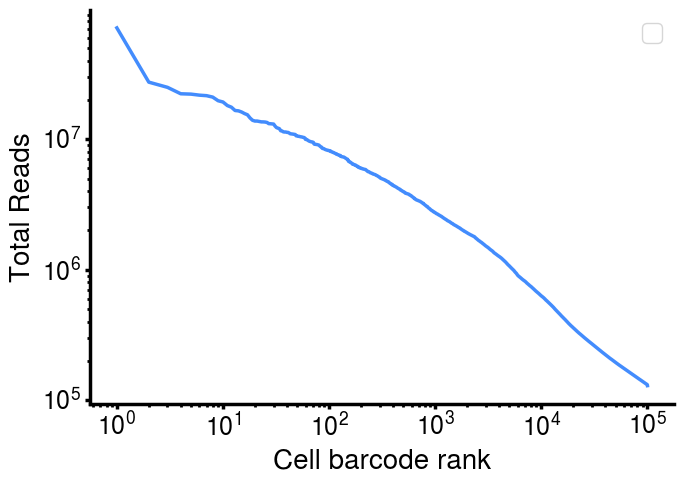

In [7]:
counts_descending = data.total_reads.sort_values(ascending=False)
n = len(counts_descending)
ranks = np.arange(1, n + 1)

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(ranks, counts_descending, color=colors[2], linewidth=2.5)

# plt.axvline(x=3000, color=colors[0], label='predicted cells', linestyle='--', linewidth=2.5)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Cell barcode rank", fontsize=20)
ax.set_ylabel("Total Reads", fontsize=20)
plt.legend(fontsize=18)

ax.tick_params(labelsize=18)
fig.tight_layout()
sns.despine()

In [8]:
# cells = data.unique_aligned_reads.sort_values(ascending=False)[:3000].index.to_list()
# data['classification'] = data.apply(lambda row: 'Cell' if row.name in cells else 'Empty Capsule', axis=1)
# data[data['classification']=='Cell']['bam_path'].to_csv('../results/worm6_final/real_cells.csv')

In [9]:
data['classification'] = data.apply(lambda row: 'Cell' if row.pct_1x>0.1 else 'Empty Capsule', axis=1)

In [10]:
real_cells = data[data["pct_1x"]>0.1]['bam_path']
real_cells.to_csv('../results/worm6_final/real_cells.csv')

In [11]:
data_sorted = data.sort_values(by='unique_aligned_reads', ascending=False)
data_sorted['rank'] = np.arange(1, len(data_sorted) + 1)
# data_sorted

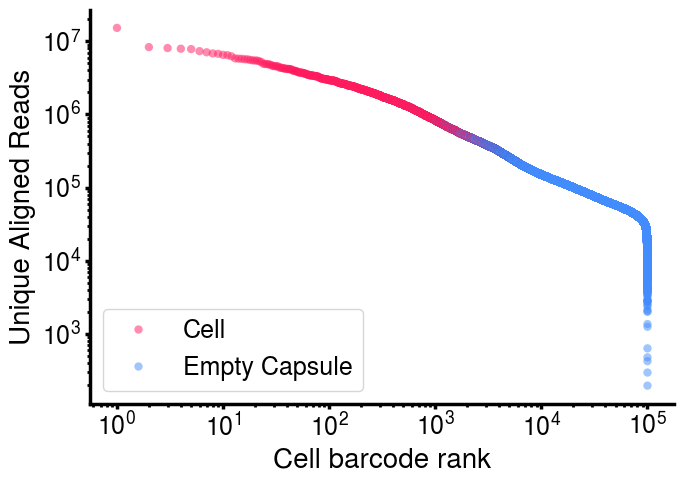

In [12]:
counts_descending = data.unique_aligned_reads.sort_values(ascending=False)
n = len(counts_descending)
ranks = np.arange(1, n + 1)

fig, ax = plt.subplots(figsize=(7, 5))

# ax.plot(ranks, counts_descending, color=colors[2], linewidth=2.5)
sns.scatterplot(data=data_sorted, x='rank', y='unique_aligned_reads',
                linewidth=0,
                alpha=0.5,
                hue='classification',
                palette={'Cell':colors[0], 'Empty Capsule':colors[2]},
               )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Cell barcode rank", fontsize=20)
ax.set_ylabel("Unique Aligned Reads", fontsize=20)
plt.legend(fontsize=18)

ax.tick_params(labelsize=18)
fig.tight_layout()
sns.despine()

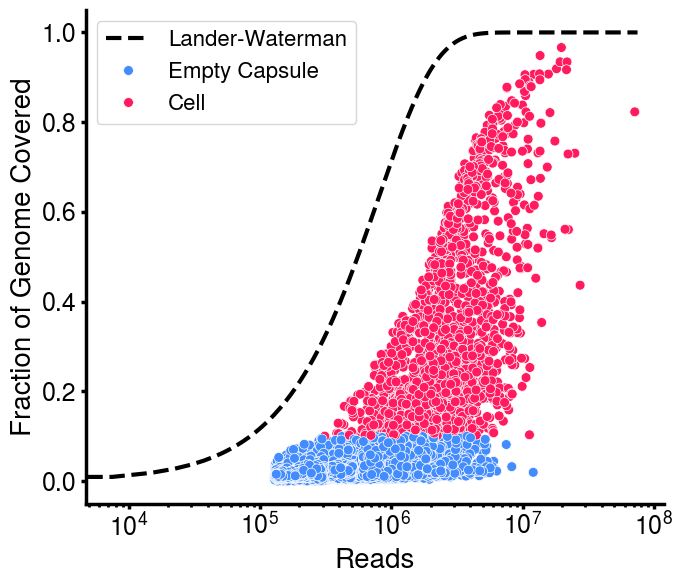

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(7, 6))

G = 100286401
RL = 125
x_theory = np.linspace(0, data['total_reads'].max() * 1.05, 10000)
y_theory = 1 - np.exp(-(x_theory * RL / G))

ax.plot(x_theory, y_theory, color='black', linestyle='--', linewidth=3, label='Lander-Waterman')
sns.scatterplot(
    data=data,
    x="total_reads",
    y="pct_1x",
    hue='classification',
    palette={'Cell':colors[0], 'Empty Capsule':colors[2]},
    ec="white",
    linewidth=0.5,
    s=50,
    # alpha=0.5,
    zorder=3,
    ax=ax,
)
plt.legend(title=False, fontsize=16)
ax.set_xlabel("Reads", fontsize=20)
ax.set_ylabel("Fraction of Genome Covered", fontsize=20)
# ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1000:g}'))
ax.tick_params(labelsize=18)

plt.xscale('log')
sns.despine()
plt.tight_layout()
# fig.savefig('', bbox_inches='tight', dpi=600)

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23],
 [Text(0, 0, 'worm6_UDI18'),
  Text(1, 0, 'worm6_UDI7'),
  Text(2, 0, 'worm6_UDI24'),
  Text(3, 0, 'worm6_UDI4'),
  Text(4, 0, 'worm6_UDI20'),
  Text(5, 0, 'worm6_UDI1'),
  Text(6, 0, 'worm6_UDI2'),
  Text(7, 0, 'worm6_UDI10'),
  Text(8, 0, 'worm6_UDI3'),
  Text(9, 0, 'worm6_UDI9'),
  Text(10, 0, 'worm6_UDI5'),
  Text(11, 0, 'worm6_UDI23'),
  Text(12, 0, 'worm6_UDI8'),
  Text(13, 0, 'worm6_UDI14'),
  Text(14, 0, 'worm6_UDI6'),
  Text(15, 0, 'worm6_UDI11'),
  Text(16, 0, 'worm6_UDI17'),
  Text(17, 0, 'worm6_UDI19'),
  Text(18, 0, 'worm6_UDI16'),
  Text(19, 0, 'worm6_UDI12'),
  Text(20, 0, 'worm6_UDI22'),
  Text(21, 0, 'worm6_UDI21'),
  Text(22, 0, 'worm6_UDI15'),
  Text(23, 0, 'worm6_UDI13')])

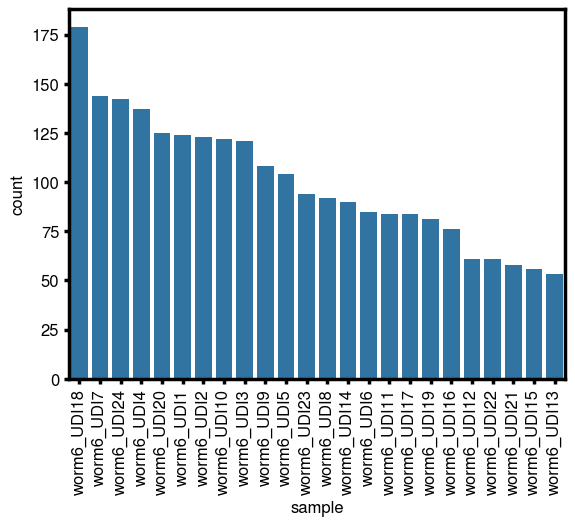

In [14]:
sns.barplot(data=data[data['classification']=='Cell'].value_counts('sample'))
plt.xticks(rotation=90)

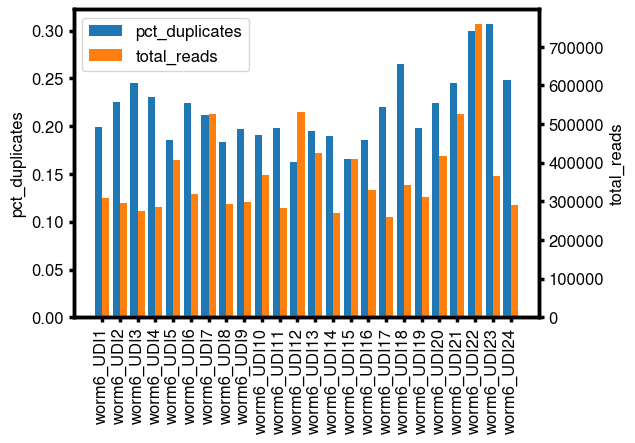

In [15]:
d = data.groupby('sample', sort=False)[['pct_duplicates','total_reads']].mean()  # drop if already 1 row/sample
x = np.arange(len(d))
w = 0.4

fig, ax1 = plt.subplots(figsize=(max(6, 0.25*len(d)), 4))
ax2 = ax1.twinx()

b1 = ax1.bar(x - w/2, d['pct_duplicates'], width=w, color='C0', label='pct_duplicates')
b2 = ax2.bar(x + w/2, d['total_reads'],    width=w, color='C1', label='total_reads')

ax1.set_xticks(x)
ax1.set_xticklabels(d.index, rotation=90)
ax1.set_ylabel('pct_duplicates'); ax2.set_ylabel('total_reads')
ax1.set_zorder(ax2.get_zorder()+1); ax1.patch.set_visible(False)  # keeps ax1 bars clickable/on top
ax1.legend(handles=[b1, b2], loc='upper left')

# dark figures

In [16]:
plt.style.use("dark_background")

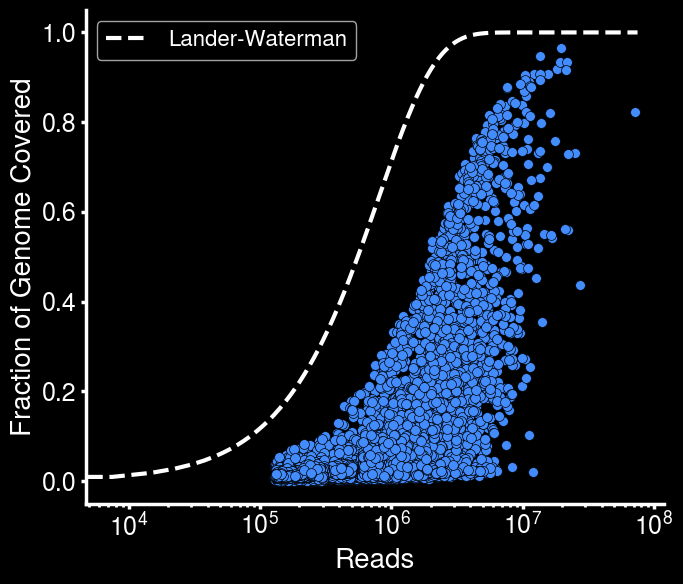

In [19]:
fig, ax = plt.subplots(1, 1, figsize=(7, 6))

G = 100286401
RL = 125
x_theory = np.linspace(0, data['total_reads'].max() * 1.05, 10000)
y_theory = 1 - np.exp(-(x_theory * RL / G))

ax.plot(x_theory, y_theory, color='white', linestyle='--', linewidth=3, label='Lander-Waterman')
sns.scatterplot(
    data=data,
    x="total_reads",
    y="pct_1x",
    # hue='classification',
    # palette={'Cell':colors[0], 'Empty Capsule':colors[2]},
    color=colors[2],
    ec="black",
    linewidth=0.5,
    s=50,
    # alpha=0.5,
    zorder=3,
    ax=ax,
)
plt.legend(title=False, fontsize=16)
ax.set_xlabel("Reads", fontsize=20)
ax.set_ylabel("Fraction of Genome Covered", fontsize=20)
# ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1000:g}'))
ax.tick_params(labelsize=18)

plt.xscale('log')
sns.despine()
plt.tight_layout()
fig.savefig('../../presentation_figures/worm06/lander_waterman.png', bbox_inches='tight', dpi=600, transparent=True)